# 🏠 Real Estate Investment Advisor
## Step 3: Model Training + MLflow Tracking

**Dataset:** `data/cleaned_data.csv`

---
| Task | Target | Models | Metrics |
|------|--------|--------|---------|
| Classification | `Good_Investment` (0/1) | 5 models | Accuracy, F1, ROC-AUC |
| Regression | `Future_Price_5Y` (₹) | 5 models | RMSE, MAE, R² |

> ✅ **SVM Fix:** Slow `SVC` replaced with fast `LinearSVC` wrapped in `CalibratedClassifierCV`  
> ✅ **Added:** `DecisionTreeClassifier` as the 5th model

---
## 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split
from sklearn.linear_model     import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble         import RandomForestClassifier, RandomForestRegressor
from sklearn.tree             import DecisionTreeClassifier
from sklearn.svm              import LinearSVC
from sklearn.calibration      import CalibratedClassifierCV
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor

import mlflow
import mlflow.sklearn

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#8b949e','ytick.color':'#8b949e',
    'text.color':'#c9d1d9','grid.color':'#21262d',
    'grid.linestyle':'--','axes.titlesize':13,
    'axes.titleweight':'bold','axes.titlecolor':'#ffffff',
})
TEAL,PURPLE,AMBER,ROSE,BLUE = '#00c9a7','#818cf8','#f59e0b','#f43f5e','#38bdf8'
PALETTE = [TEAL, PURPLE, AMBER, ROSE, BLUE]

os.makedirs('models', exist_ok=True)
print('✅ All libraries imported!')

✅ All libraries imported!


---
## 1️⃣ Load Cleaned Dataset

In [2]:
df = pd.read_csv('data/cleaned_data.csv')
print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

✅ Loaded: 229,980 rows × 27 columns


,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Owner_Type,Availability_Status,Amenity_Count,Floor_Ratio,Amenity_Density_Score,Is_Ready_to_Move,Has_Parking,Has_Security,Future_Price_5Y,Good_Investment
0,0.789474,0.146341,0.967936,0.0,0.00,0.942222,0.979102,0.313658,0.000000,0.0,...,1.0,0.0,1.00,0.733333,0.087230,1,0,0,719.618119,0
1,0.578947,0.804878,0.869739,0.5,0.50,0.414222,0.378612,0.249821,0.545455,1.0,...,0.5,1.0,1.00,0.066667,0.195414,0,0,1,287.283026,1
2,0.684211,0.609756,0.150301,0.0,0.25,0.698222,0.354673,0.149987,0.212121,0.5,...,0.0,0.0,0.75,0.045238,0.091663,1,1,0,270.047807,1


---
## 2️⃣ Define Features & Targets — Train/Test Split (80/20)

In [3]:
TARGET_CLF = 'Good_Investment'
TARGET_REG = 'Future_Price_5Y'

X     = df.drop(columns=[TARGET_CLF, TARGET_REG])
y_clf = df[TARGET_CLF]
y_reg = df[TARGET_REG]

joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Features  : {X.shape[1]} columns')
print(f'Train set : {X_train.shape[0]:,} rows (80%)')
print(f'Test  set : {X_test.shape[0]:,}  rows (20%)')
print(f'Good_Investment → {y_clf.value_counts().to_dict()}')
print('✅ Split done!')

Features  : 25 columns
Train set : 183,984 rows (80%)
Test  set : 45,996  rows (20%)
Good_Investment → {1: 122002, 0: 107978}
✅ Split done!


---
## 3️⃣ MLflow Setup

In [4]:
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('Real_Estate_Investment_Advisor')
print('✅ MLflow ready!')
print('   After training run:  mlflow ui')
print('   Then open        :  http://127.0.0.1:5000')

2026/03/11 08:58:06 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Investment_Advisor' does not exist. Creating a new experiment.


✅ MLflow ready!
   After training run:  mlflow ui
   Then open        :  http://127.0.0.1:5000


---
# 🔵 PART A — CLASSIFICATION
### Target: `Good_Investment` (0 = Not Good, 1 = Good)

| # | Model | Note |
|---|-------|------|
| 1 | Logistic Regression | Fast, interpretable |
| 2 | Decision Tree | Fast, visual |
| 3 | Random Forest | Ensemble, accurate |
| 4 | XGBoost | Boosted, most accurate |
| 5 | LinearSVC | ✅ Fast SVM alternative |

In [5]:
# CalibratedClassifierCV gives LinearSVC the ability to output
# probabilities — required for ROC-AUC score calculation
fast_svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))

classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'LinearSVC'           : fast_svm
}

print('Classification Models:')
for i, name in enumerate(classifiers, 1):
    print(f'  {i}. {name}')

Classification Models:
  1. Logistic Regression
  2. Decision Tree
  3. Random Forest
  4. XGBoost
  5. LinearSVC


In [6]:
clf_results         = []
trained_classifiers = {}

print('=' * 60)
print('TRAINING CLASSIFICATION MODELS')
print('=' * 60)

for name, model in classifiers.items():
    print(f'\n🔄 Training: {name}...')
    with mlflow.start_run(run_name=f'CLF_{name.replace(" ","_")}'):
        model.fit(X_train, y_clf_train)
        y_pred      = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]

        acc     = accuracy_score(y_clf_test,  y_pred)
        prec    = precision_score(y_clf_test, y_pred, zero_division=0)
        rec     = recall_score(y_clf_test,    y_pred, zero_division=0)
        f1      = f1_score(y_clf_test,        y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_clf_test,   y_pred_prob)

        mlflow.log_param('model_name', name)
        mlflow.log_param('task', 'classification')
        mlflow.log_metric('accuracy',  acc)
        mlflow.log_metric('precision', prec)
        mlflow.log_metric('recall',    rec)
        mlflow.log_metric('f1_score',  f1)
        mlflow.log_metric('roc_auc',   roc_auc)
        mlflow.sklearn.log_model(model, name=f'clf_{name.replace(" ","_")}')

    clf_results.append({'Model':name,'Accuracy':round(acc,4),
                        'Precision':round(prec,4),'Recall':round(rec,4),
                        'F1_Score':round(f1,4),'ROC_AUC':round(roc_auc,4)})
    trained_classifiers[name] = model
    print(f'   ✅ Accuracy={acc:.4f} | F1={f1:.4f} | ROC-AUC={roc_auc:.4f}')

print('\n' + '='*60)
print('✅ All 5 Classifiers Trained!')
print('='*60)

TRAINING CLASSIFICATION MODELS

🔄 Training: Logistic Regression...


2026/03/11 08:58:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   ✅ Accuracy=0.9116 | F1=0.9169 | ROC-AUC=0.9764

🔄 Training: Decision Tree...


2026/03/11 08:58:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   ✅ Accuracy=0.9949 | F1=0.9952 | ROC-AUC=0.9975

🔄 Training: Random Forest...


...

   ✅ Accuracy=0.9959 | F1=0.9962 | ROC-AUC=0.9999

🔄 Training: XGBoost...


2026/03/11 08:59:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   ✅ Accuracy=0.9981 | F1=0.9982 | ROC-AUC=1.0000

🔄 Training: LinearSVC...


2026/03/11 08:59:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   ✅ Accuracy=0.9117 | F1=0.9171 | ROC-AUC=0.9764

✅ All 5 Classifiers Trained!


## 📊 Classification — Results & Charts

In [7]:
clf_df = pd.DataFrame(clf_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
clf_df.index += 1
print('📊 Classification Results (sorted by ROC-AUC):')
print(clf_df.to_string())
print(f'\n🏆 Best: {clf_df.iloc[0]["Model"]}  |  ROC-AUC={clf_df.iloc[0]["ROC_AUC"]}  |  Accuracy={clf_df.iloc[0]["Accuracy"]}')

📊 Classification Results (sorted by ROC-AUC):
                 Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
1              XGBoost    0.9981     0.9982  0.9983    0.9982   1.0000
2        Random Forest    0.9959     0.9966  0.9957    0.9962   0.9999
3        Decision Tree    0.9949     0.9955  0.9949    0.9952   0.9975
4  Logistic Regression    0.9116     0.9141  0.9197    0.9169   0.9764
5            LinearSVC    0.9117     0.9142  0.9200    0.9171   0.9764

🏆 Best: XGBoost  |  ROC-AUC=1.0  |  Accuracy=0.9981


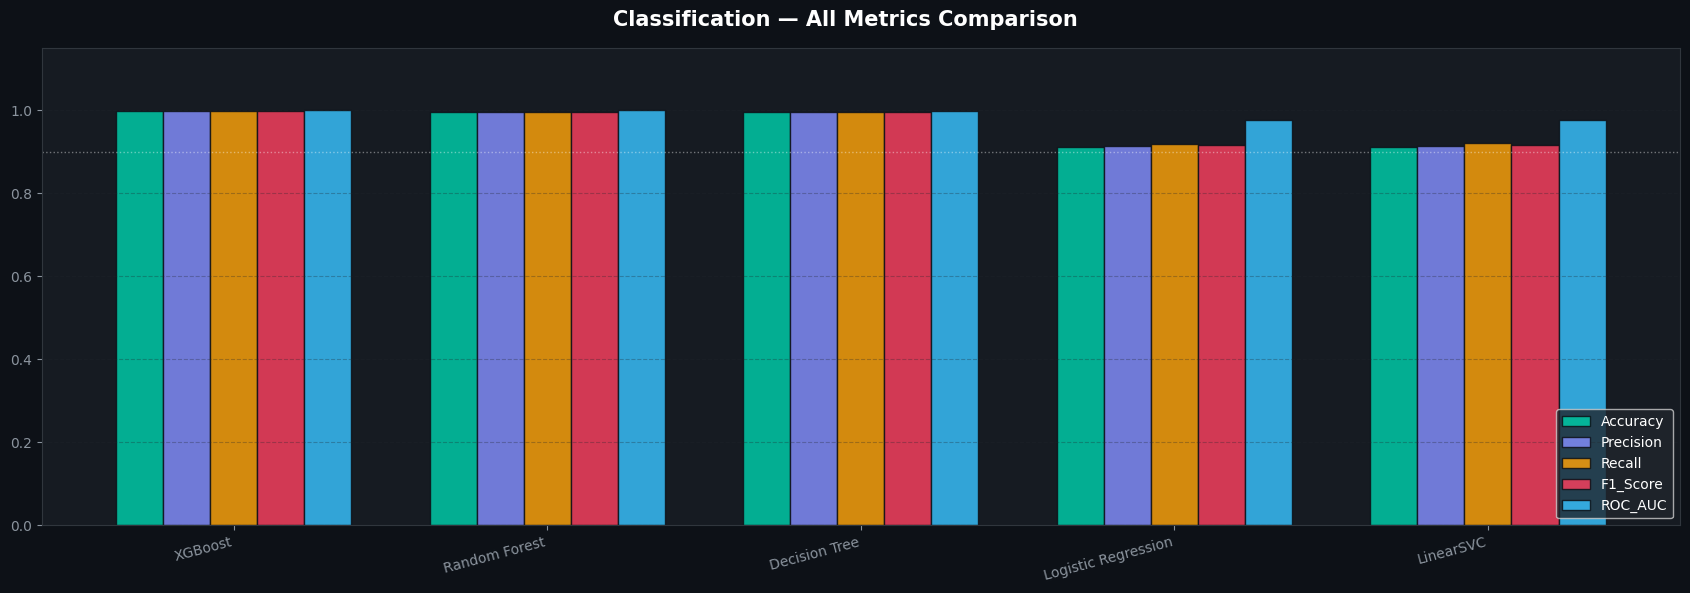

In [8]:
metrics = ['Accuracy','Precision','Recall','F1_Score','ROC_AUC']
x, w    = np.arange(len(clf_df)), 0.15

fig, ax = plt.subplots(figsize=(17, 6))
fig.suptitle('Classification — All Metrics Comparison', fontsize=15, fontweight='bold', color='white')
for i,(m,c) in enumerate(zip(metrics,PALETTE)):
    ax.bar(x+i*w, clf_df[m], w, label=m, color=c, edgecolor='#0d1117', alpha=0.85)
ax.set_xticks(x+w*2)
ax.set_xticklabels(clf_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0,1.15)
ax.axhline(0.9,color='white',linestyle=':',linewidth=1,alpha=0.4)
ax.legend(facecolor='#21262d',labelcolor='white',loc='lower right')
ax.grid(True,alpha=0.3,axis='y')
plt.tight_layout()
plt.show()

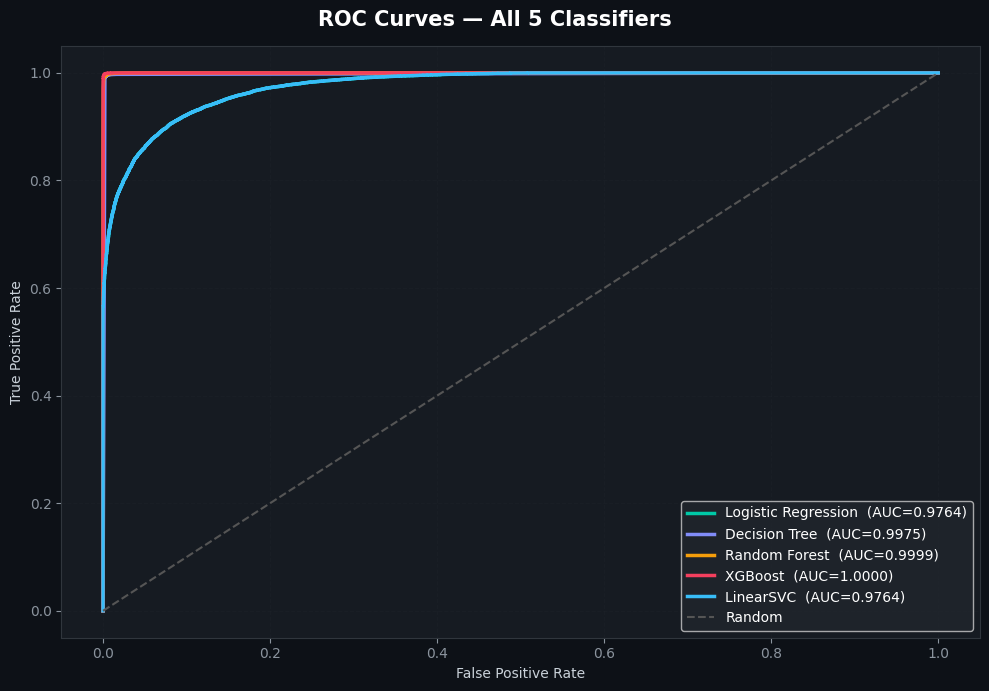

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('ROC Curves — All 5 Classifiers', fontsize=15, fontweight='bold', color='white')
for (name,model),color in zip(trained_classifiers.items(),PALETTE):
    prob       = model.predict_proba(X_test)[:,1]
    fpr,tpr,_  = roc_curve(y_clf_test, prob)
    auc        = roc_auc_score(y_clf_test, prob)
    ax.plot(fpr,tpr,color=color,linewidth=2.5,label=f'{name}  (AUC={auc:.4f})')
ax.plot([0,1],[0,1],color='#555',linestyle='--',linewidth=1.5,label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(facecolor='#21262d',labelcolor='white',fontsize=10)
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

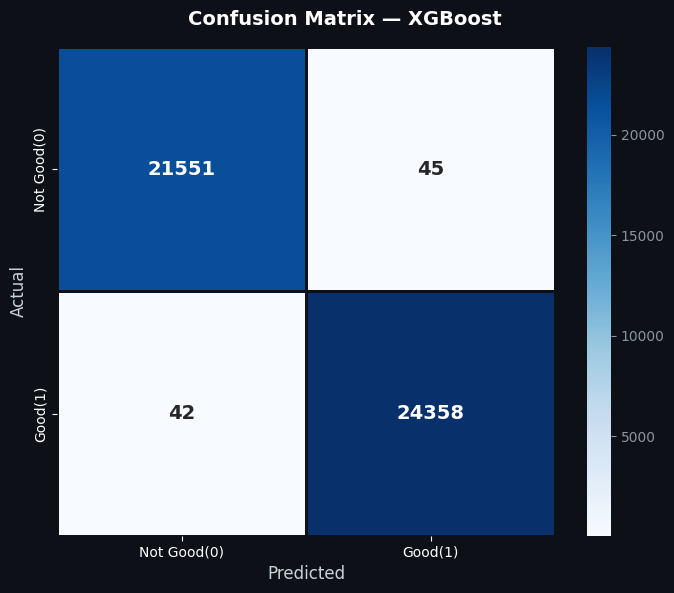


📌 Best Model: XGBoost
   TP=24,358  TN=21,551  FP=45  FN=42


In [10]:
best_clf_name  = clf_df.iloc[0]['Model']
best_clf_model = trained_classifiers[best_clf_name]
y_pred_best    = best_clf_model.predict(X_test)
cm = confusion_matrix(y_clf_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7,6))
fig.suptitle(f'Confusion Matrix — {best_clf_name}', fontsize=14, fontweight='bold', color='white')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Good(0)','Good(1)'],
            yticklabels=['Not Good(0)','Good(1)'],
            linewidths=1, linecolor='#0d1117',
            annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Predicted',fontsize=12)
ax.set_ylabel('Actual',fontsize=12)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

tn,fp,fn,tp = cm.ravel()
print(f'\n📌 Best Model: {best_clf_name}')
print(f'   TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}')

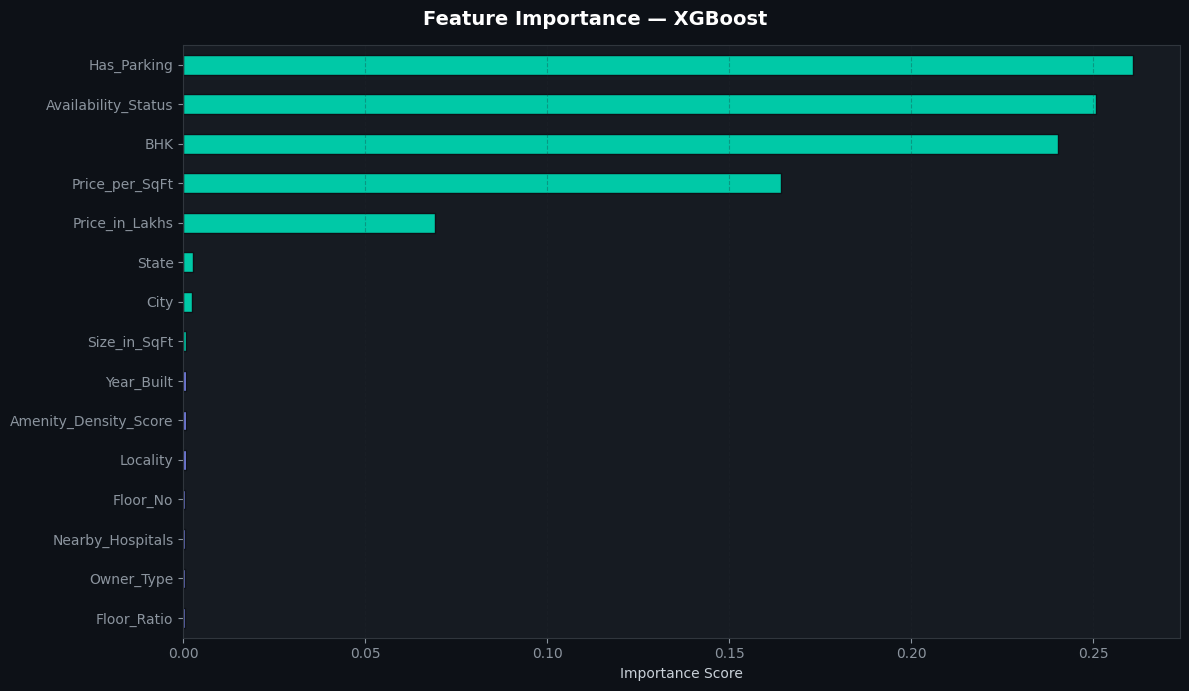

In [11]:
if hasattr(best_clf_model,'feature_importances_'):
    imp = pd.Series(best_clf_model.feature_importances_,index=X.columns).sort_values(ascending=True).tail(15)
    fig,ax = plt.subplots(figsize=(12,7))
    fig.suptitle(f'Feature Importance — {best_clf_name}',fontsize=14,fontweight='bold',color='white')
    imp.plot(kind='barh',ax=ax,color=[TEAL if v>=imp.median() else PURPLE for v in imp.values],edgecolor='#0d1117')
    ax.set_xlabel('Importance Score')
    ax.grid(True,alpha=0.3,axis='x')
    plt.tight_layout()
    plt.show()
else:
    print(f'ℹ️  {best_clf_name} — feature importance not directly available.')

---
# 🟠 PART B — REGRESSION
### Target: `Future_Price_5Y` (₹ Lakhs after 5 years)

| # | Model |
|---|-------|
| 1 | Linear Regression |
| 2 | Ridge Regression |
| 3 | Lasso Regression |
| 4 | Random Forest Regressor |
| 5 | XGBoost Regressor |

In [12]:
regressors = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Lasso Regression'  : Lasso(alpha=0.1, max_iter=5000),
    'Random Forest Reg' : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost Reg'       : XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}
print('Regression Models:')
for i,name in enumerate(regressors,1):
    print(f'  {i}. {name}')

Regression Models:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. Random Forest Reg
  5. XGBoost Reg


In [13]:
reg_results        = []
trained_regressors = {}

print('='*60)
print('TRAINING REGRESSION MODELS')
print('='*60)

for name,model in regressors.items():
    print(f'\n🔄 Training: {name}...')
    with mlflow.start_run(run_name=f'REG_{name.replace(" ","_")}'):
        model.fit(X_train, y_reg_train)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
        mae  = mean_absolute_error(y_reg_test, y_pred)
        r2   = r2_score(y_reg_test, y_pred)
        mlflow.log_param('model_name', name)
        mlflow.log_param('task', 'regression')
        mlflow.log_metric('rmse', rmse)
        mlflow.log_metric('mae',  mae)
        mlflow.log_metric('r2',   r2)
        mlflow.sklearn.log_model(model, name=f'reg_{name.replace(" ","_")}')
    reg_results.append({'Model':name,'RMSE':round(rmse,4),'MAE':round(mae,4),'R2':round(r2,4)})
    trained_regressors[name] = model
    print(f'   ✅ RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}')

print('\n'+'='*60)
print('✅ All 5 Regressors Trained!')
print('='*60)

TRAINING REGRESSION MODELS

🔄 Training: Linear Regression...


2026/03/11 09:00:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   ✅ RMSE=0.0000 | MAE=0.0000 | R²=1.0000

🔄 Training: Ridge Regression...


2026/03/11 09:00:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   ✅ RMSE=0.0283 | MAE=0.0219 | R²=1.0000

🔄 Training: Lasso Regression...


...

   ✅ RMSE=0.3514 | MAE=0.3034 | R²=1.0000

🔄 Training: Random Forest Reg...


2026/03/11 09:01:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/11 09:01:38 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\ELCOT\AppData\Local\Temp\tmpzwwasyln\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


   ✅ RMSE=0.0038 | MAE=0.0024 | R²=1.0000

🔄 Training: XGBoost Reg...


2026/03/11 09:01:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   ✅ RMSE=0.8256 | MAE=0.7094 | R²=1.0000

✅ All 5 Regressors Trained!


## 📊 Regression — Results & Charts

In [14]:
reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
reg_df.index += 1
print('📊 Regression Results (sorted by R²):')
print(reg_df.to_string())
print(f'\n🏆 Best: {reg_df.iloc[0]["Model"]}  |  R²={reg_df.iloc[0]["R2"]}  |  RMSE={reg_df.iloc[0]["RMSE"]}')

📊 Regression Results (sorted by R²):
               Model    RMSE     MAE   R2
1  Linear Regression  0.0000  0.0000  1.0
2   Ridge Regression  0.0283  0.0219  1.0
3   Lasso Regression  0.3514  0.3034  1.0
4  Random Forest Reg  0.0038  0.0024  1.0
5        XGBoost Reg  0.8256  0.7094  1.0

🏆 Best: Linear Regression  |  R²=1.0  |  RMSE=0.0


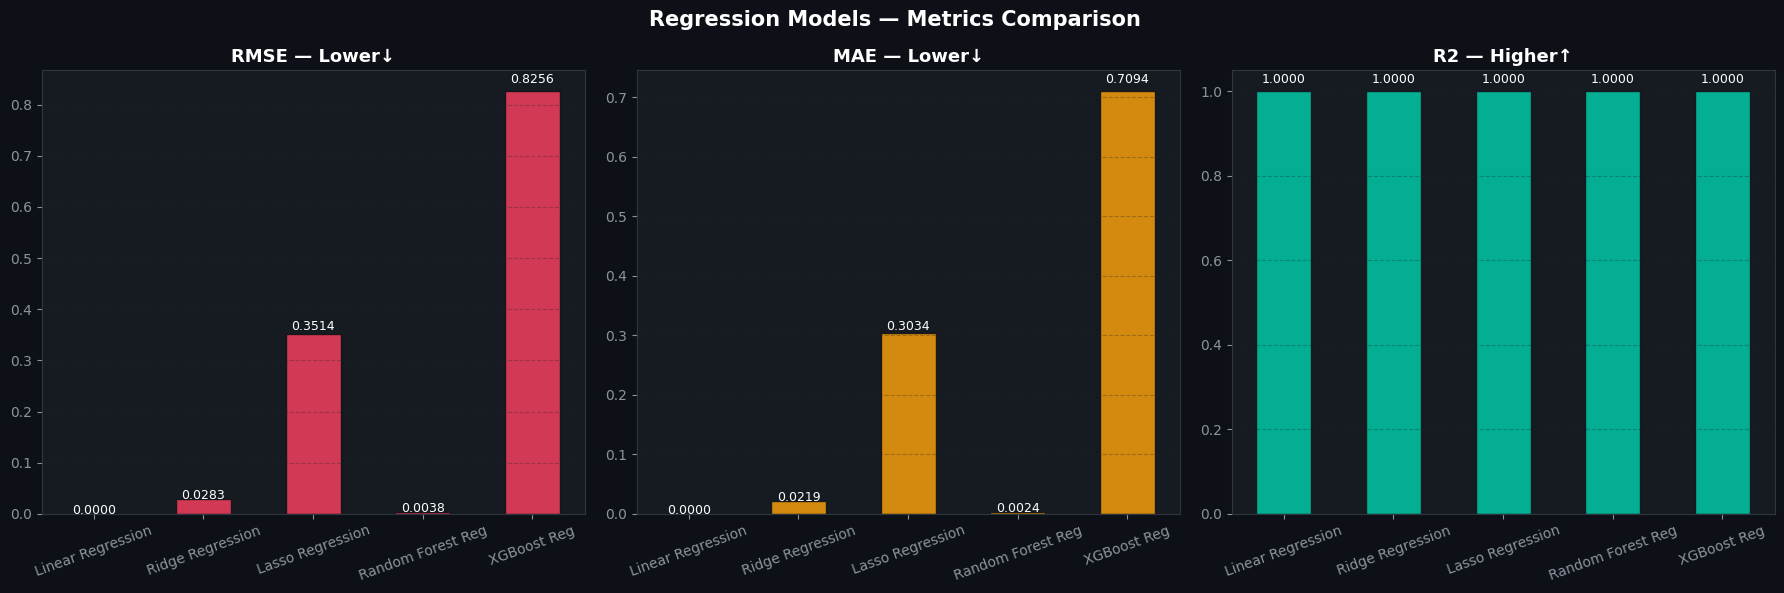

In [15]:
fig, axes = plt.subplots(1,3,figsize=(18,6))
fig.suptitle('Regression Models — Metrics Comparison',fontsize=15,fontweight='bold',color='white')
for ax,(metric,color,note) in zip(axes,[('RMSE',ROSE,'Lower↓'),('MAE',AMBER,'Lower↓'),('R2',TEAL,'Higher↑')]):
    bars = ax.bar(reg_df['Model'],reg_df[metric],color=color,edgecolor='#0d1117',alpha=0.85,width=0.5)
    for bar,val in zip(bars,reg_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.02,f'{val:.4f}',ha='center',fontsize=9,color='white')
    ax.set_title(f'{metric} — {note}')
    ax.tick_params(axis='x',rotation=20)
    ax.grid(True,alpha=0.3,axis='y')
plt.tight_layout()
plt.show()

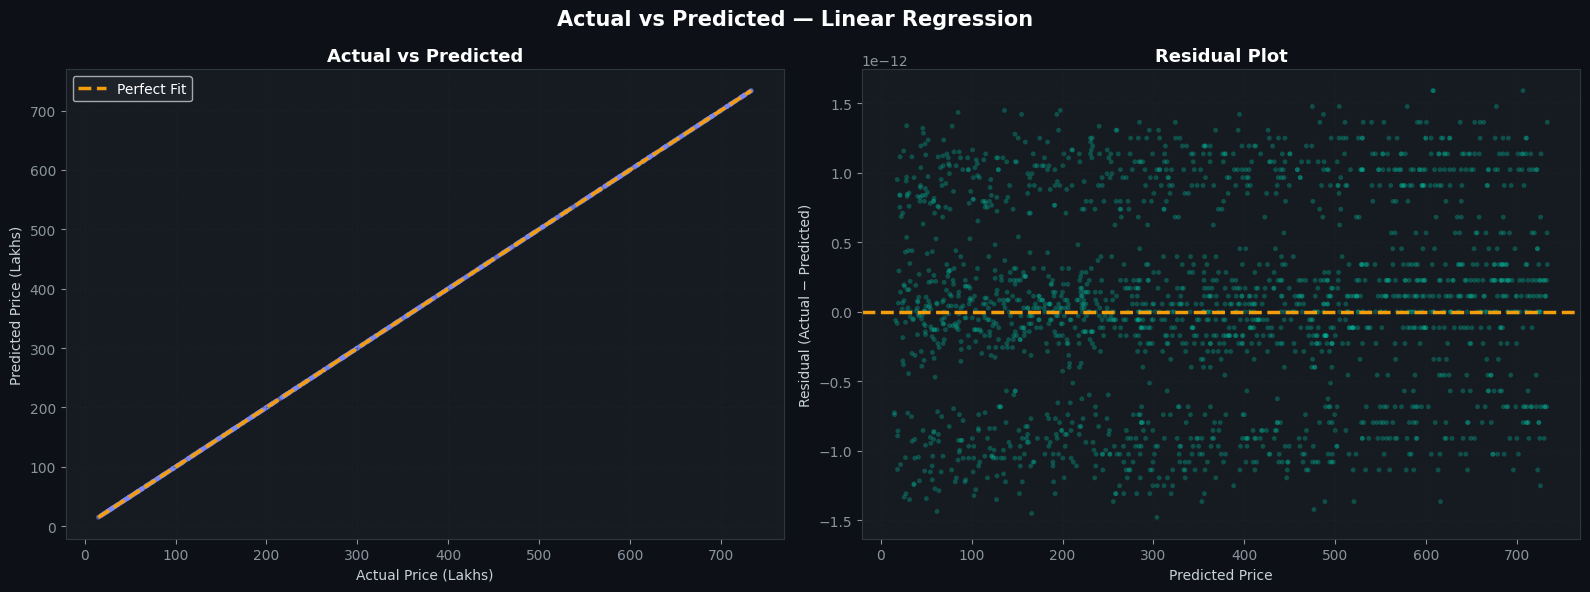


📌 Mean Residual: 0.0000  |  Std: 0.0000


In [16]:
best_reg_name  = reg_df.iloc[0]['Model']
best_reg_model = trained_regressors[best_reg_name]
y_pred_reg     = best_reg_model.predict(X_test)

idx           = np.random.choice(len(y_reg_test), size=min(2000,len(y_reg_test)), replace=False)
actual_s      = np.array(y_reg_test)[idx]
pred_s        = y_pred_reg[idx]
residuals     = actual_s - pred_s

fig,axes = plt.subplots(1,2,figsize=(16,6))
fig.suptitle(f'Actual vs Predicted — {best_reg_name}',fontsize=15,fontweight='bold',color='white')

axes[0].scatter(actual_s,pred_s,alpha=0.3,color=PURPLE,s=12,edgecolors='none')
mn,mx = min(actual_s.min(),pred_s.min()), max(actual_s.max(),pred_s.max())
axes[0].plot([mn,mx],[mn,mx],color=AMBER,linewidth=2.5,linestyle='--',label='Perfect Fit')
axes[0].set_xlabel('Actual Price (Lakhs)')
axes[0].set_ylabel('Predicted Price (Lakhs)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend(facecolor='#21262d',labelcolor='white')
axes[0].grid(True,alpha=0.3)

axes[1].scatter(pred_s,residuals,alpha=0.3,color=TEAL,s=12,edgecolors='none')
axes[1].axhline(0,color=AMBER,linewidth=2.5,linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()
print(f'\n📌 Mean Residual: {residuals.mean():.4f}  |  Std: {residuals.std():.4f}')

In [17]:
if hasattr(best_reg_model,'feature_importances_'):
    imp = pd.Series(best_reg_model.feature_importances_,index=X.columns).sort_values(ascending=True).tail(15)
    fig,ax = plt.subplots(figsize=(12,7))
    fig.suptitle(f'Feature Importance — {best_reg_name}',fontsize=14,fontweight='bold',color='white')
    imp.plot(kind='barh',ax=ax,color=[AMBER if v>=imp.median() else BLUE for v in imp.values],edgecolor='#0d1117')
    ax.set_xlabel('Importance Score')
    ax.grid(True,alpha=0.3,axis='x')
    plt.tight_layout()
    plt.show()
else:
    print(f'ℹ️  {best_reg_name} — feature importance not directly available.')

ℹ️  Linear Regression — feature importance not directly available.


---
## 💾 Save Best Models

In [18]:
joblib.dump(best_clf_model, 'models/best_classifier.pkl')
joblib.dump(best_reg_model, 'models/best_regressor.pkl')
joblib.dump({
    'best_classifier_name' : best_clf_name,
    'best_regressor_name'  : best_reg_name,
    'clf_metrics'          : clf_df.iloc[0].to_dict(),
    'reg_metrics'          : reg_df.iloc[0].to_dict(),
    'clf_all_results'      : clf_df.to_dict(),
    'reg_all_results'      : reg_df.to_dict()
}, 'models/model_info.pkl')

print(f'✅ best_classifier.pkl saved  →  {best_clf_name}  (ROC-AUC={clf_df.iloc[0]["ROC_AUC"]})')
print(f'✅ best_regressor.pkl  saved  →  {best_reg_name}  (R²={reg_df.iloc[0]["R2"]})')
print(f'✅ model_info.pkl      saved')

✅ best_classifier.pkl saved  →  XGBoost  (ROC-AUC=1.0)
✅ best_regressor.pkl  saved  →  Linear Regression  (R²=1.0)
✅ model_info.pkl      saved


---
## ✅ Verify All Files

In [19]:
files = [
    'data/cleaned_data.csv',
    'models/label_encoders.pkl',
    'models/scaler.pkl',
    'models/feature_names.pkl',
    'models/best_classifier.pkl',
    'models/best_regressor.pkl',
    'models/model_info.pkl'
]
print('📁 Project Files:')
print('-'*52)
all_ok = True
for f in files:
    ok   = os.path.exists(f)
    size = os.path.getsize(f)/1024 if ok else 0
    print(f'  {"✅" if ok else "❌"}  {size:8.1f} KB  →  {f}')
    if not ok: all_ok = False
print('-'*52)
print('🎉 All files ready! → Next: Streamlit App' if all_ok else '⚠️  Re-run missing notebooks')

📁 Project Files:
----------------------------------------------------
  ✅   71672.2 KB  →  data/cleaned_data.csv
  ✅      10.3 KB  →  models/label_encoders.pkl
  ✅       2.1 KB  →  models/scaler.pkl
  ✅       0.4 KB  →  models/feature_names.pkl
  ✅     353.9 KB  →  models/best_classifier.pkl
  ✅       1.5 KB  →  models/best_regressor.pkl
  ✅       1.0 KB  →  models/model_info.pkl
----------------------------------------------------
🎉 All files ready! → Next: Streamlit App


---
## 🚀 View Results in MLflow UI

In [20]:
print('Open a NEW terminal in VS Code and run:')
print()
print('    mlflow ui')
print()
print('Then open your browser → http://127.0.0.1:5000')
print()
print('You will see:')
print('  ✅  5 Classification runs  (CLF_Logistic_Regression, CLF_XGBoost ...)')
print('  ✅  5 Regression runs      (REG_Linear_Regression, REG_XGBoost_Reg ...)')
print('  ✅  All metrics logged     (accuracy, f1, roc_auc, rmse, mae, r2)')
print('  ✅  Saved model artifacts')

Open a NEW terminal in VS Code and run:

    mlflow ui

Then open your browser → http://127.0.0.1:5000

You will see:
  ✅  5 Classification runs  (CLF_Logistic_Regression, CLF_XGBoost ...)
  ✅  5 Regression runs      (REG_Linear_Regression, REG_XGBoost_Reg ...)
  ✅  All metrics logged     (accuracy, f1, roc_auc, rmse, mae, r2)
  ✅  Saved model artifacts


---
## 🎉 Final Summary

In [21]:
print('='*60)
print('       MODEL TRAINING COMPLETE!')
print('='*60)
print()
print('CLASSIFICATION RESULTS:')
print(clf_df.to_string())
print()
print('REGRESSION RESULTS:')
print(reg_df.to_string())
print()
print(f'🏆 Best Classifier : {best_clf_name}')
print(f'🏆 Best Regressor  : {best_reg_name}')
print()
print('→ Next Step: Streamlit App (app.py)')
print('='*60)

       MODEL TRAINING COMPLETE!

CLASSIFICATION RESULTS:
                 Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
1              XGBoost    0.9981     0.9982  0.9983    0.9982   1.0000
2        Random Forest    0.9959     0.9966  0.9957    0.9962   0.9999
3        Decision Tree    0.9949     0.9955  0.9949    0.9952   0.9975
4  Logistic Regression    0.9116     0.9141  0.9197    0.9169   0.9764
5            LinearSVC    0.9117     0.9142  0.9200    0.9171   0.9764

REGRESSION RESULTS:
               Model    RMSE     MAE   R2
1  Linear Regression  0.0000  0.0000  1.0
2   Ridge Regression  0.0283  0.0219  1.0
3   Lasso Regression  0.3514  0.3034  1.0
4  Random Forest Reg  0.0038  0.0024  1.0
5        XGBoost Reg  0.8256  0.7094  1.0

🏆 Best Classifier : XGBoost
🏆 Best Regressor  : Linear Regression

→ Next Step: Streamlit App (app.py)
